# Vehicle Mileage Prediction
### Sikem Nkwawir

## Introduction

This project focuses on developing models to predict the miles per gallon (mpg) of cars using Python. The goal is to create two types of models: a traditional, least-square linear regression and a stochastic gradient descent model. To achieve this I will use multiple libraries, including Pandas for data manipulation, NumPy for calculations, Seaborn and Matplotlib for visualization, and Missingno to deal with missing values. I will use Scikit-learn (sklearn) for creating my model. By using features like horsepower and weight of the car, I hope to create models that can accurately predict what the mpg is.


## 0. Set Up: Importing all the necessary libraries

In [4]:
import pandas as pd
import numpy as np
import seaborn as sb
import missingno as msno
from matplotlib.pyplot import hist,bar
from sklearn import preprocessing as pp
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [5]:
pip install ucimlrepo


## 1. Data Input

In [6]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
auto_mpg = fetch_ucirepo(id=9)

# data (as pandas dataframes)
X = auto_mpg.data.features
y = auto_mpg.data.targets


ampg = pd.DataFrame(auto_mpg.data.original)




The code above imports the required dataset and converts it into a data frame so it can be manipulated and used to make my models.

In [ ]:
print("The dimensions of my dataset are:", ampg.shape)
print(ampg.head())
print(ampg.tail())

The dimensions of our dataset are: (398, 9)
                    car_name  cylinders  displacement  horsepower  weight  \
0  chevrolet,chevelle,malibu          8         307.0       130.0    3504   
1          buick,skylark,320          8         350.0       165.0    3693   
2         plymouth,satellite          8         318.0       150.0    3436   
3              amc,rebel,sst          8         304.0       150.0    3433   
4                ford,torino          8         302.0       140.0    3449   

   acceleration  model_year  origin   mpg  
0          12.0          70       1  18.0  
1          11.5          70       1  15.0  
2          11.0          70       1  18.0  
3          12.0          70       1  16.0  
4          10.5          70       1  17.0  
            car_name  cylinders  displacement  horsepower  weight  \
393  ford,mustang,gl          4         140.0        86.0    2790   
394        vw,pickup          4          97.0        52.0    2130   
395    dodge,rampage  

The code above is to make sure the data frame is initialized correctly. First I check the size of the data frame and then the top and buttom of it.

## 2. Data Cleaning and Preparation

I start by checking my data for any missing values and visualize them to see if there is any pattern in their poisitions.

In [8]:
ampg.replace(('?','NA'), np.nan, inplace=True)
ampg.isnull().sum()

,0
car_name,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
mpg,0


<Axes: >

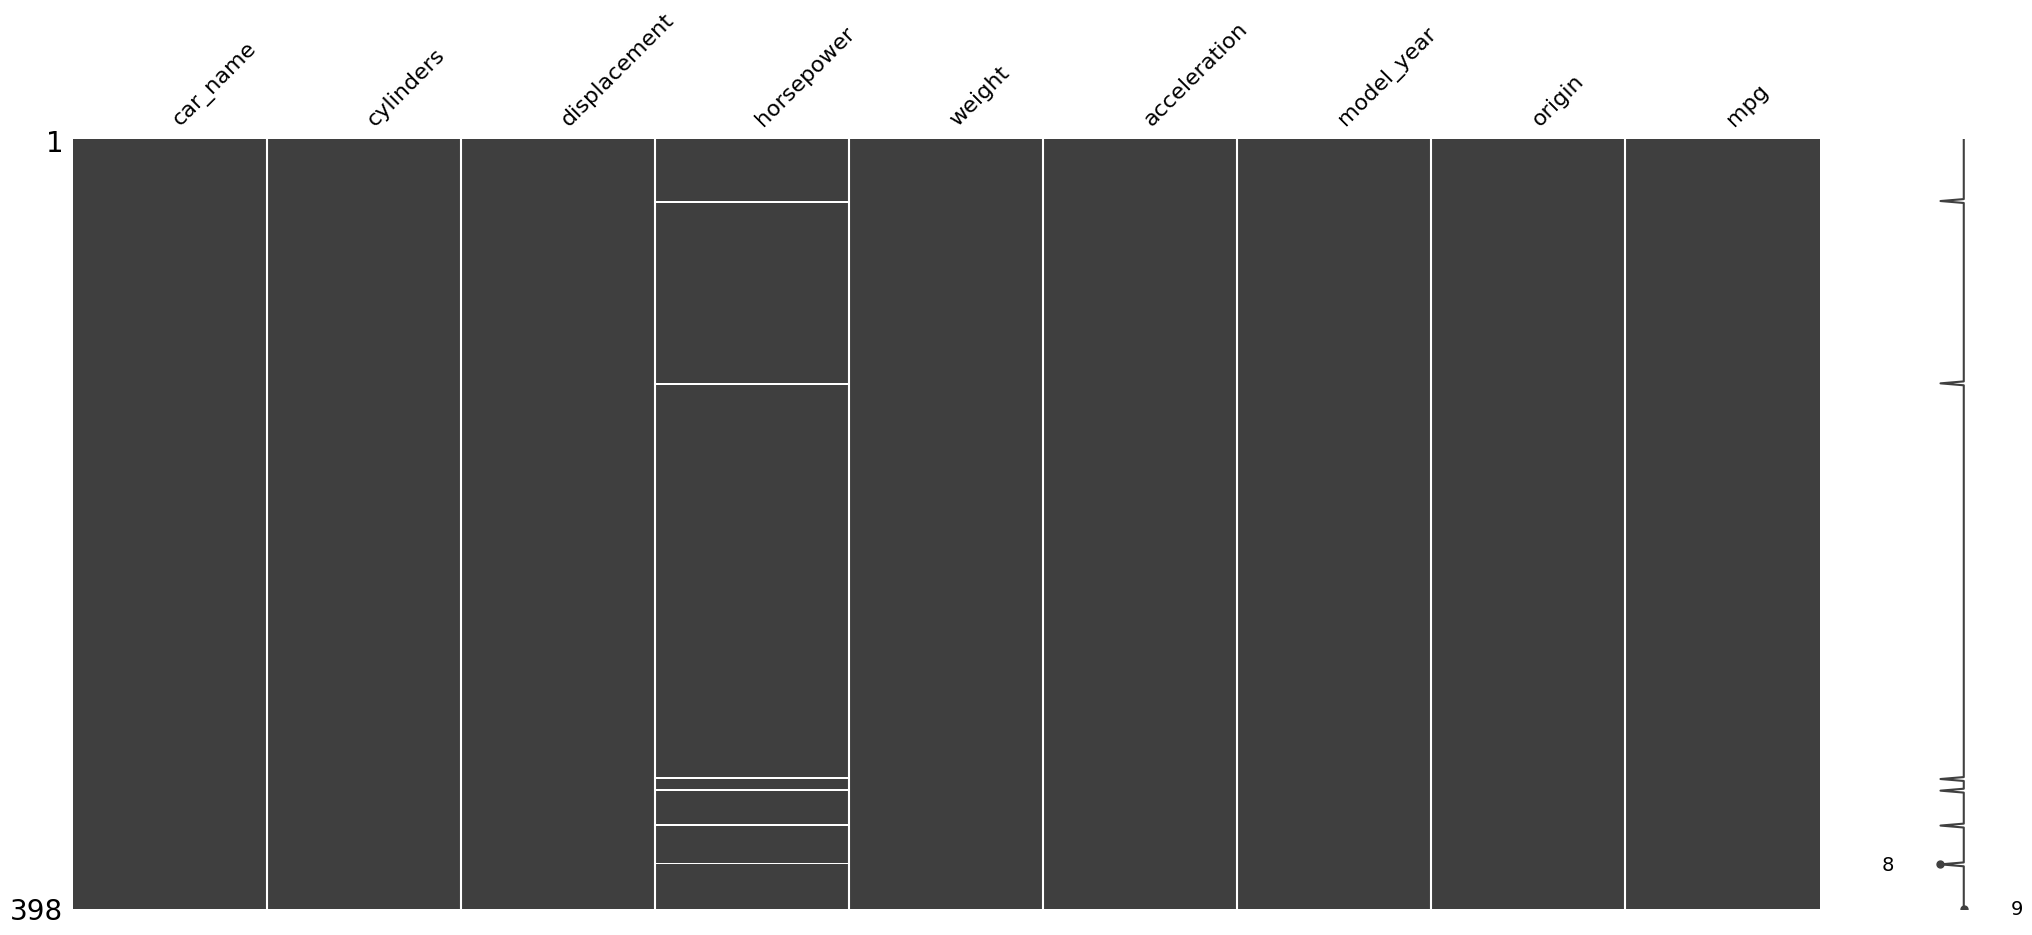

In [9]:
msno.matrix(ampg)

I see that there are 6 missing values in the horsepower column. This can be fixed by replacing them with the mean of the rest of the data in the column. After that, I recheck my data to ensure I have the same time and fixed all the missing values.

In [10]:
ampg['horsepower'] = pd.to_numeric(ampg['horsepower'], errors='coerce')
ampg['horsepower'] = ampg['horsepower'].fillna(ampg['horsepower'].mean())
ampg.shape

(398, 9)

In [11]:
ampg.isnull().sum()

,0
car_name,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0
mpg,0


## 3. Feature Engineering

First, I will come up with some additional variables that are derived from my existing features.

In [12]:
ampg['power-to-weight']=ampg['horsepower']/ampg['weight']
ampg['horsepower-per-cylinder']=ampg['horsepower']/ampg['cylinders']
ampg['weight-per-cylinder']=ampg['weight']/ampg['cylinders']
ampg['displacement*weight']=ampg['displacement']*ampg['weight']

Next, I will create dummy variables to represent my categorical feature, origin. Since there are 3 categories, I only need 2 dummy variables. This is so I can avoid unstability caused by multi-collinearity. Once I create these dummy variables, I add them into my data frame.

In [13]:
dummies = pd.get_dummies(ampg['origin'], drop_first= True)
dummies.head()

,2,3
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False


In [14]:
ampgd = pd.concat([ampg, dummies], axis=1)
ampgd.head(6)

,car_name,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg,power-to-weight,horsepower-per-cylinder,weight-per-cylinder,displacement*weight,2,3
0,"chevrolet,chevelle,malibu",8,307.0,130.0,3504,12.0,70,1,18.0,0.037100,16.250,438.000,1075728.0,False,False
1,"buick,skylark,320",8,350.0,165.0,3693,11.5,70,1,15.0,0.044679,20.625,461.625,1292550.0,False,False
2,"plymouth,satellite",8,318.0,150.0,3436,11.0,70,1,18.0,0.043655,18.750,429.500,1092648.0,False,False
3,"amc,rebel,sst",8,304.0,150.0,3433,12.0,70,1,16.0,0.043694,18.750,429.125,1043632.0,False,False
4,"ford,torino",8,302.0,140.0,3449,10.5,70,1,17.0,0.040591,17.500,431.125,1041598.0,False,False
5,"ford,galaxie,500",8,429.0,198.0,4341,10.0,70,1,15.0,0.045612,24.750,542.625,1862289.0,False,False


Next, I want to check the distribution of the target variable mpg. Ideally, I want each value for mpg to be equally represented. While my overall data is skewed, I still have over 10 values for every mog value below 40. Although 10-15 is underrepresented, the large amount of data found in the adjacent range should help. Based on the plot, I should get the least accurate predictions for mpg values higher than 40, as they are the least represented and also do not have much data in the adjacent range.

(array([13., 78., 73., 61., 54., 48., 38., 22.,  5.,  6.]),
 array([ 9.  , 12.76, 16.52, 20.28, 24.04, 27.8 , 31.56, 35.32, 39.08,
        42.84, 46.6 ]),
 <BarContainer object of 10 artists>)

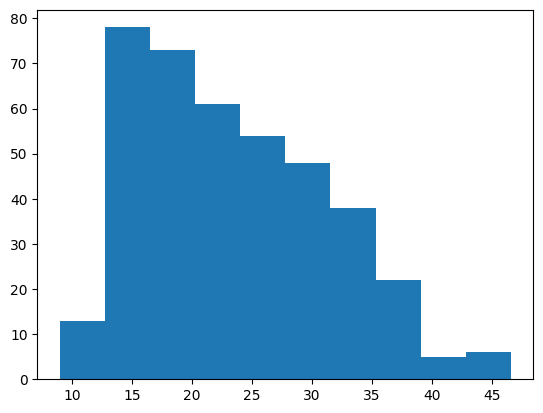

In [15]:
hist(ampgd['mpg'])

In [16]:

print(ampgd.head(6))
ampgd.info()

                    car_name  cylinders  displacement  horsepower  weight  \
0  chevrolet,chevelle,malibu          8         307.0       130.0    3504   
1          buick,skylark,320          8         350.0       165.0    3693   
2         plymouth,satellite          8         318.0       150.0    3436   
3              amc,rebel,sst          8         304.0       150.0    3433   
4                ford,torino          8         302.0       140.0    3449   
5           ford,galaxie,500          8         429.0       198.0    4341   

   acceleration  model_year  origin   mpg  power-to-weight  \
0          12.0          70       1  18.0         0.037100   
1          11.5          70       1  15.0         0.044679   
2          11.0          70       1  18.0         0.043655   
3          12.0          70       1  16.0         0.043694   
4          10.5          70       1  17.0         0.040591   
5          10.0          70       1  15.0         0.045612   

   horsepower-per-cylinde

I are now ready to scale my features using StandardScaler() and split my data into 75% training data and 25% test data. I have to scale my data because I are dealing with multiple orders of magnitude. Scaling will help my regression models adjust the parameters correctly.

In [17]:
X= ampgd[['model_year','cylinders','displacement','horsepower','weight',
          'acceleration', 'power-to-weight','origin','displacement*weight',
          'weight-per-cylinder','horsepower-per-cylinder']]
y= ampgd['mpg']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



## 4. Traditional Linear Regression

Here I will create my first model using the LinearRegression funtion from sklearn. I will them print the MSE and R-squared values so that I can both confirm that it worked and compare it to my second model.

In [18]:
model1 = LinearRegression()
model1.fit(X_train_scaled, y_train)

y_pred1 = model1.predict(X_test_scaled)
mse1 = mean_squared_error(y_test, y_pred1)
r2_1 = r2_score(y_test, y_pred1)

print("Traditional Linear Regression:")
print(f"Mean Squared Error: {mse1:.4f}")
print(f"R-squared: {r2_1:.4f}")

Traditional Linear Regression:
Mean Squared Error: 6.6544
R-squared: 0.8828


## 5. Gradient Descent and Hyper-Parameter Tuning

My next order of business is to create my second model. This time, I use the SGDRegressor function, also from sklearn. Before I use this function, I must create a parameter grid, which holds different possible values for learning rate, initial learning rate, number of iterations and loss function. I will use GridSearchCV in order to pick the best hyper-parameters from the grid.

In [19]:
param_grid = {
    'learning_rate': ['constant', 'optimal', 'adaptive'],
    'eta0': [0.005, 0.01, 0.05, 0.1],  # Initial learning rate
    'max_iter': [4470, 7450, 11920, 29800],  # Number of iterations. Note: each
    #value is a multiple of 298, which is about 75% of 398
    'loss': ['squared_error', 'huber']  # Different loss functions
}

sgd_regressor = SGDRegressor(random_state=42)

# Use GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(estimator=sgd_regressor, param_grid=param_grid,
                           scoring='neg_mean_squared_error', cv=3)
best_par = grid_search.fit(X_train_scaled, y_train)

After completing my parameter search, I use my new model to predict mpg values. Once again, I will take note of the MSE and R-squared. I will also take note of the hyper-parameters that were chosen to build this model. I set the random state to 42 to make sure that I get consistent results when run.

In [20]:
# Best model from grid search
best_model = grid_search.best_estimator_

y_pred2 = best_model.predict(X_test_scaled)
mse2 = mean_squared_error(y_test, y_pred2)
r2_2 = r2_score(y_test, y_pred2)

print("\nSGDRegressor with GridSearchCV:")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Mean Squared Error: {mse2:.4f}")
print(f"R-squared: {r2_2:.4f}")


SGDRegressor with GridSearchCV:
Best Parameters: {'eta0': 0.05, 'learning_rate': 'adaptive', 'loss': 'squared_error', 'max_iter': 4470}
Mean Squared Error: 6.6310
R-squared: 0.8832


## Comparison

The MSE and R-squared scores for the models suggest that model2 is better than model1. Model2 had both a higher R-squared (0.8828 vs 0.8832) and a lower MSE (6.6544 vs 6.6310). The difference is very small, having an error difference of only 0.234. This is expected, as the LinearRegression function does not iterate. If the number of iterations were not a multiple of the amount of training data, it is likely that the SGDRegressor would be less accurate. This is because it would be biased towards the observations in the data from the remainder.

Based on the following plots, I can confirm that the prediction lines are very similar. It is also interesting to note that while more accurate, my SGDRegressor model has more outlier residuals than my tradional linear model. Like I expected, both models have their least accurate prediction at the only mpg value in my test data above 40.

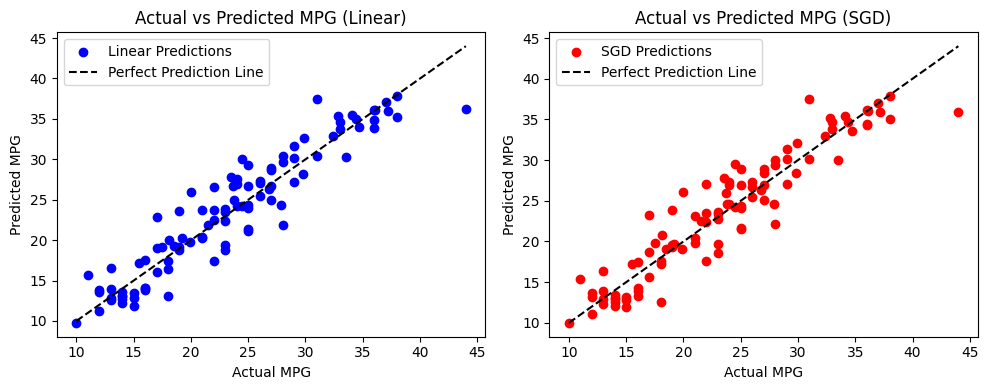

In [21]:
plt.figure(figsize=(10, 4))

# Plot for Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred1, color='blue', label='Linear Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--',
         color='black', label='Perfect Prediction Line')
plt.title('Actual vs Predicted MPG (Linear)')
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.legend()

# Plot for SGD Regressor
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred2, color='red', label='SGD Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--',
         color='black', label='Perfect Prediction Line')
plt.title('Actual vs Predicted MPG (SGD)')
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.legend()

plt.tight_layout()
plt.show()


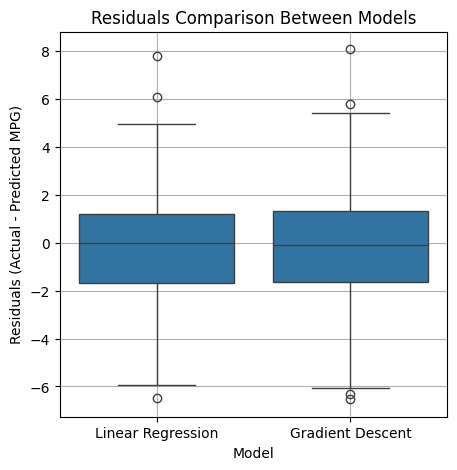

In [23]:
# Calculate residuals for both models
residuals_lr = y_test - y_pred1  # Residuals for Linear Regression
residuals_gd = y_test - y_pred2 # Residuals for Gradient Descent

# Combine residuals into a long-form DataFrame for easy plotting
residuals_data = pd.DataFrame({
    'Residuals': np.concatenate([residuals_lr, residuals_gd]),
    'Model': ['Linear Regression'] * len(residuals_lr) + ['Gradient Descent'] *
    len(residuals_gd)
})

# Visualize Residuals using Box Plots
plt.figure(figsize=(5, 5))
sb.boxplot(x='Model', y='Residuals', data=residuals_data)
plt.title('Residuals Comparison Between Models')
plt.ylabel('Residuals (Actual - Predicted MPG)')
plt.grid(True)
plt.show()
